In [1]:
import numpy as np
import matplotlib.pyplot as plt

import gps

# Setup

In [2]:
f_s = 2.6e6
x = np.fromfile("gpssim.bin", dtype=np.int8)

x = x[::2].astype(np.complex64) + 1j*x[1::2].astype(np.complex64)

# Acquisition

In [3]:
results = gps.acquisition(x, f_s, 10e3, 500)

print(len(results))

# Refine frequency estimates
for i in range(len(results)):
    results[i][1] = gps.fine_acquisition(x, f_s, 8192, 8, results[i][0], results[i][2])

10


In [15]:
i = 3
sv = results[i][0]
freq_est = results[i][1]
code_est = results[i][2]

(
    res_iq,
    res_carr_freq,
    res_carr_err,
    res_code_freq,
    res_code_err,
    res_code_phase,
) = gps.tracking(x, f_s, sv, freq_est, code_est, debug_results=True)

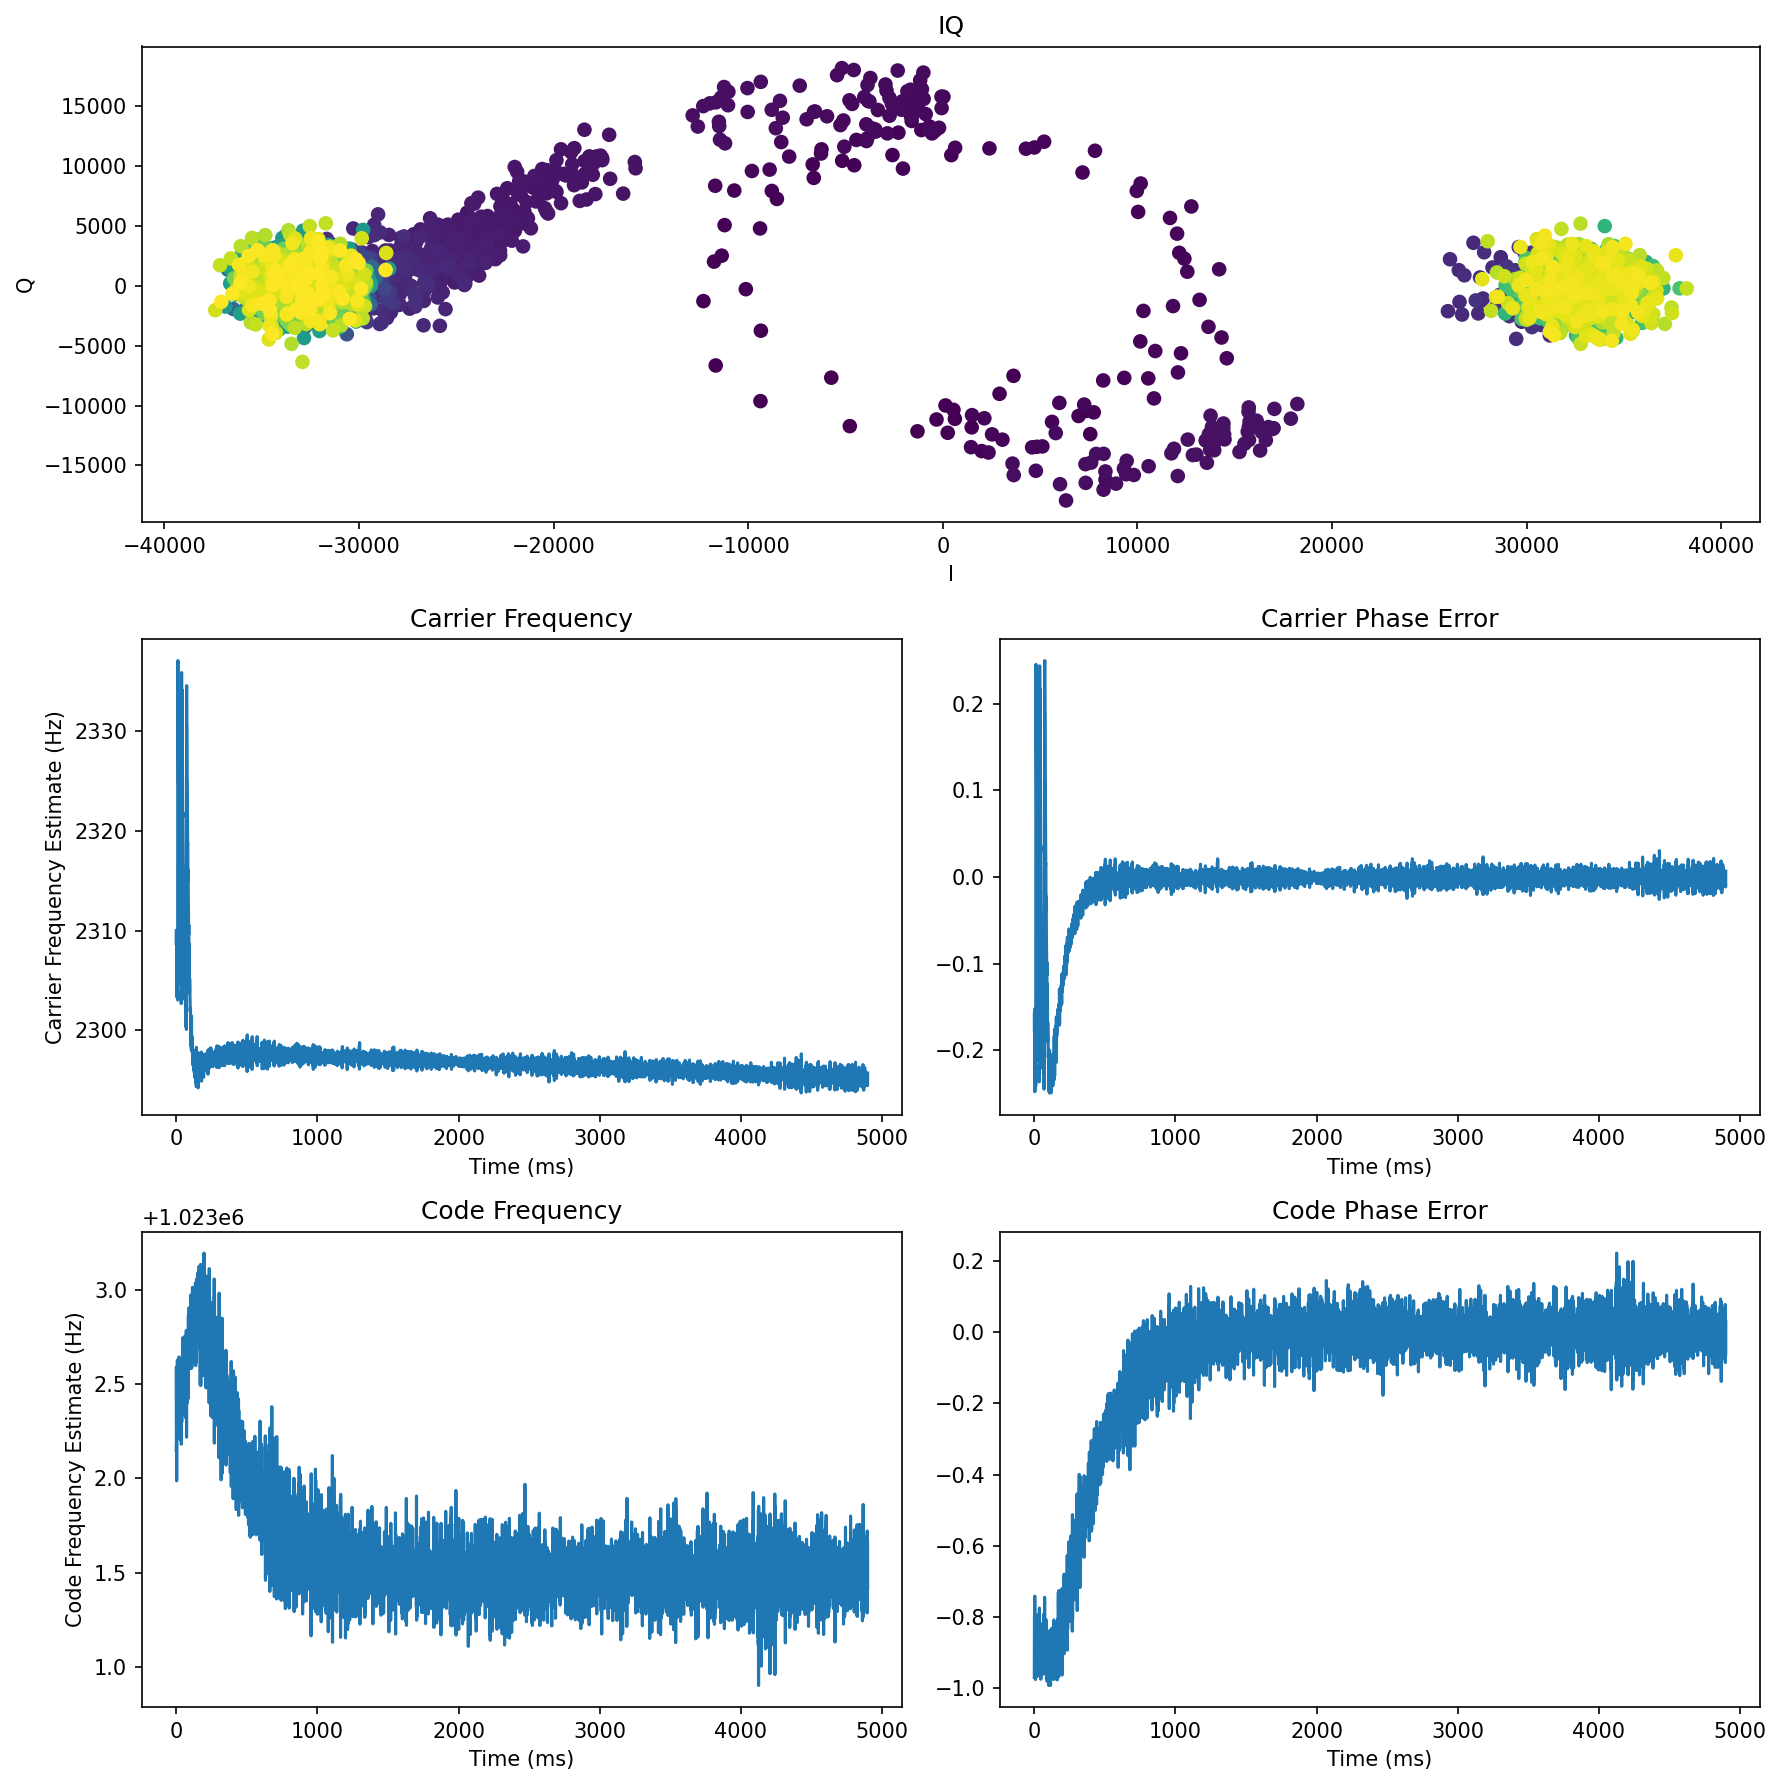

In [16]:
plt.figure(figsize=(12, 12), dpi=150)

plt.subplot(3, 2, (1, 2))
plt.scatter(res_iq.real, res_iq.imag, c=np.arange(len(res_iq)))
plt.title("IQ")
plt.xlabel("I")
plt.ylabel("Q")

plt.subplot(3, 2, 3)
plt.plot(res_carr_freq)
plt.title("Carrier Frequency")
plt.xlabel("Time (ms)")
plt.ylabel("Carrier Frequency Estimate (Hz)")

plt.subplot(3, 2, 4)
plt.plot(res_carr_err)
plt.title("Carrier Phase Error")
plt.xlabel("Time (ms)")

plt.subplot(3, 2, 5)
plt.plot(res_code_freq)
plt.title("Code Frequency")
plt.xlabel("Time (ms)")
plt.ylabel("Code Frequency Estimate (Hz)")

plt.subplot(3, 2, 6)
plt.plot(res_code_err)
plt.title("Code Phase Error")
plt.xlabel("Time (ms)")

plt.tight_layout()

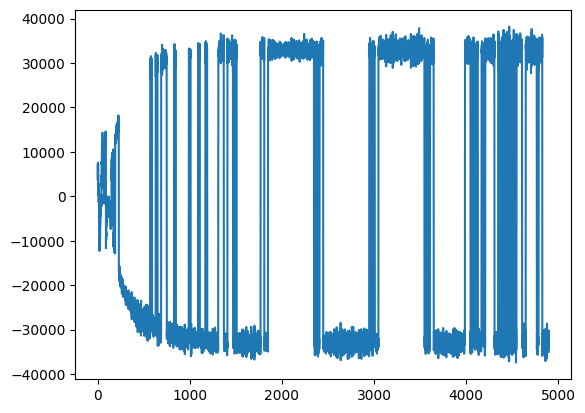

In [17]:
plt.plot(res_iq.real)